# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
import math
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_taxi = pd.read_csv('taxi.csv')

In [3]:
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [4]:
df_taxi.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [5]:
df_taxi.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [6]:
#Valores ausentes
print(df_taxi.isna().sum())

datetime      0
num_orders    0
dtype: int64


In [7]:
#Conversão para categorias
df_taxi['datetime'] = df_taxi['datetime'].astype('datetime64[ns]')
print(df_taxi['datetime'].dtype)

datetime64[ns]


In [8]:
df_taxi = df_taxi.set_index('datetime')

In [9]:
df_taxi = df_taxi.sort_index()

## Análise

In [10]:
#Análise Temporal
df_taxi = df_taxi.asfreq('1H', fill_value=0)
print("Informações do DataFrame após pré-processamento:")
df_taxi.info()
print("Primeiras 5 linhas do DataFrame:")
print(df_taxi.head())
print("Últimas 5 linhas do DataFrame:")
print(df_taxi.tail())

Informações do DataFrame após pré-processamento:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
Primeiras 5 linhas do DataFrame:
                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 01:00:00           7
2018-03-01 02:00:00          22
2018-03-01 03:00:00           8
2018-03-01 04:00:00          13
Últimas 5 linhas do DataFrame:
                     num_orders
datetime                       
2018-08-31 19:00:00          27
2018-08-31 20:00:00          33
2018-08-31 21:00:00          24
2018-08-31 22:00:00          34
2018-08-31 23:00:00          30


C:\Users\Usuário\AppData\Local\Temp\ipykernel_3708\2677914327.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_taxi = df_taxi.asfreq('1H', fill_value=0)


C:\Users\Usuário\AppData\Local\Temp\ipykernel_3708\431018051.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='num_orders', data=df_taxi, palette='rocket')


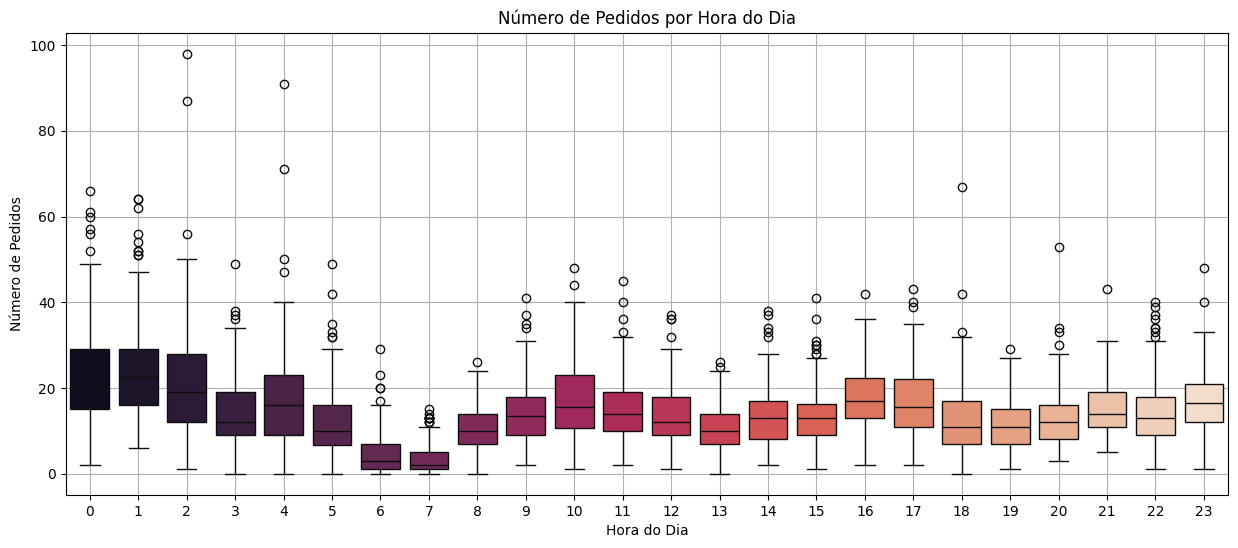

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3708\431018051.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dayofweek', y='num_orders', data=df_taxi, palette='rocket')


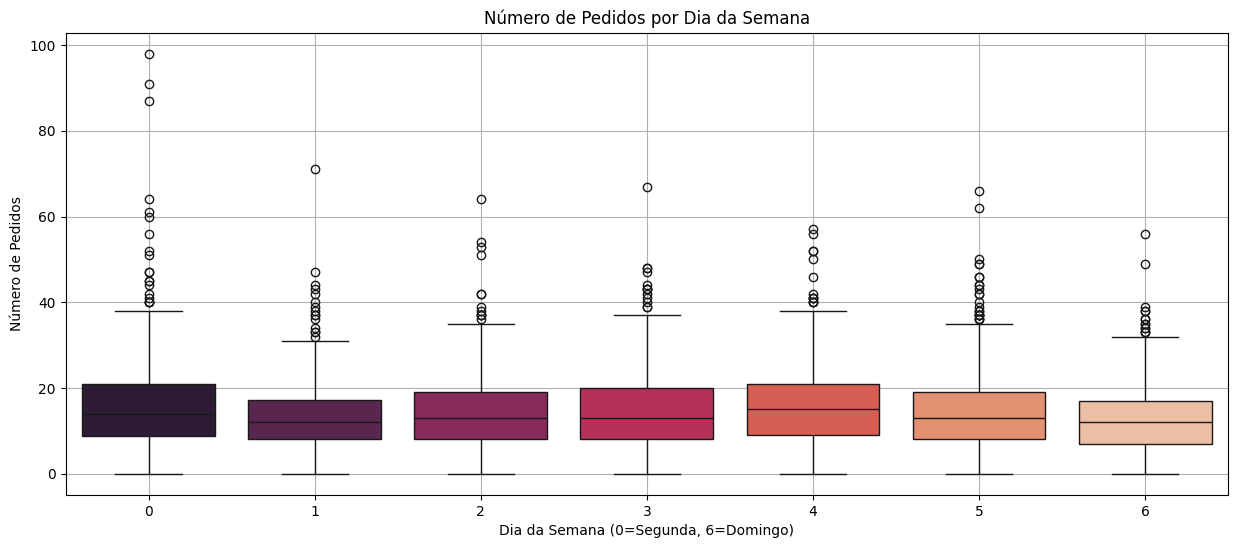

In [11]:
df_taxi['hour'] = df_taxi.index.hour
df_taxi['dayofweek'] = df_taxi.index.dayofweek # 0=Monday, 6=Sunday

plt.figure(figsize=(15, 6))
sns.boxplot(x='hour', y='num_orders', data=df_taxi, palette='rocket')
plt.title('Número de Pedidos por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(x='dayofweek', y='num_orders', data=df_taxi, palette='rocket')
plt.title('Número de Pedidos por Dia da Semana')
plt.xlabel('Dia da Semana (0=Segunda, 6=Domingo)')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()

**Conclusões**

As análises mostram claramente os padrões de demanda ao longo do dia e da semana, com a segunda-feira e as primeiras horas do dia/noite sendo os períodos de maior movimento, enquanto a madrugada, o meio da tarde e os finais de semana são mais calmos.

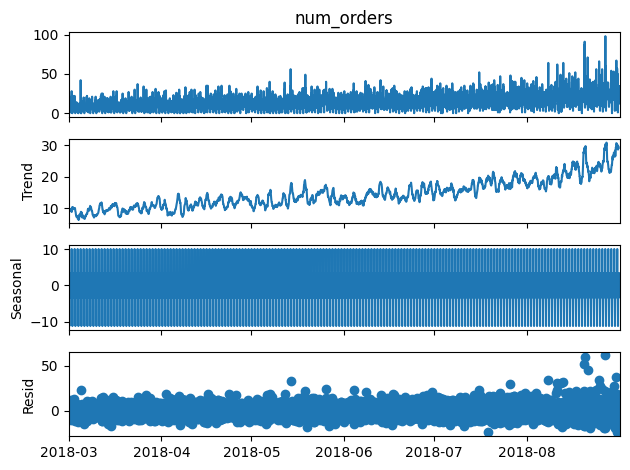

In [12]:
result = seasonal_decompose(df_taxi['num_orders'], model='additive')
result.plot()
plt.show()

**Conclusão**

O número de pedidos está crescendo consistentemente, exibindo fortes padrões sazonais. 
É crucial investigar a natureza da sazonalidade para previsão e otimização.
Além disso, os picos residuais no final do período merecem uma análise mais aprofundada para identificar as causas desses eventos incomuns e determinar se são oportunidades ou anomalias a serem gerenciadas.

## Treinamento

In [13]:
df_taxi['num_orders_shift'] = df_taxi.shift(5)['num_orders']

In [14]:
df_taxi['num_orders_shift'] = df_taxi['num_orders'].rolling(window=5).mean()

In [15]:
df_taxi = df_taxi.dropna()

In [16]:
#Treine modelos
X = df_taxi.drop(columns=['num_orders'])
y = df_taxi['num_orders']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=False)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

Tamanho do conjunto de treino (X_train): (3970, 3)
Tamanho do conjunto de teste (X_test): (442, 3)
Tamanho do conjunto de treino (y_train): (3970,)
Tamanho do conjunto de teste (y_test): (442,)


In [17]:
#Criar uma instância do modelo de Regressão Linear
model = LinearRegression()

#Treinar o modelo usando os dados de treino
model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso!")
print(f"Coeficientes do modelo: {model.coef_}")
print(f"Intercepto do modelo: {model.intercept_}")

Modelo de Regressão Linear treinado com sucesso!
Coeficientes do modelo: [ 0.02729517 -0.00743431  0.91776683]
Intercepto do modelo: 0.820130020724168


In [18]:
y_pred = model.predict(X_test)

print(f"Primeiras 5 previsões:\n{y_pred[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões:
[18.27272552 22.1546414  23.28325677 23.31055194 24.80627404]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [19]:
#Calcular o Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
#Calcular o R-quadrado (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de Determinação (R-quadrado): {r2:.2f}")

Erro Quadrático Médio (MSE): 134.05
REQM: 11.58
Coeficiente de Determinação (R-quadrado): 0.21


In [20]:
#Treinando modelo de Gradient Boosting
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train, y_train)

print("Modelo Gradient Boosting Regressor treinado com sucesso!")

Modelo Gradient Boosting Regressor treinado com sucesso!


In [21]:
y_pred_gb = model_gb.predict(X_test)

print(f"Primeiras 5 previsões do Gradient Boosting:\n{y_pred_gb[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Gradient Boosting:
[16.52179867 21.42206696 26.73571235 26.27407849 20.98543315]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [22]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Gradient Boosting: {mse_gb:.2f}")
print(f"R-squared (R2) do Gradient Boosting: {r2_gb:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Gradient Boosting: 95.49
R-squared (R2) do Gradient Boosting: 0.44


In [23]:
#Treinando modelo de Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


In [24]:
y_pred_rf = model_rf.predict(X_test)

print(f"Primeiras 5 previsões do Random Forest:\n{y_pred_rf[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Random Forest:
[15.605      16.37       22.7425     25.77583333 24.96      ]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [25]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Random Forest: {mse_rf:.2f}")
print(f"R-squared (R2) do Random Forest: {r2_rf:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Random Forest: 103.81
R-squared (R2) do Random Forest: 0.39


In [26]:
#Treinando modelo de Regressão de Árvores
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)

print("Modelo Decision Tree Regressor treinado com sucesso!")

Modelo Decision Tree Regressor treinado com sucesso!


In [27]:
y_pred_dt = model_dt.predict(X_test)

print(f"Primeiras 5 previsões do Decision Tree:\n{y_pred_dt[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Decision Tree:
[16.08196721  9.         32.         27.         27.        ]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [28]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Decision Tree: {mse_dt:.2f}")
print(f"R-squared (R2) do Decision Tree: {r2_dt:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Decision Tree: 144.51
R-squared (R2) do Decision Tree: 0.15


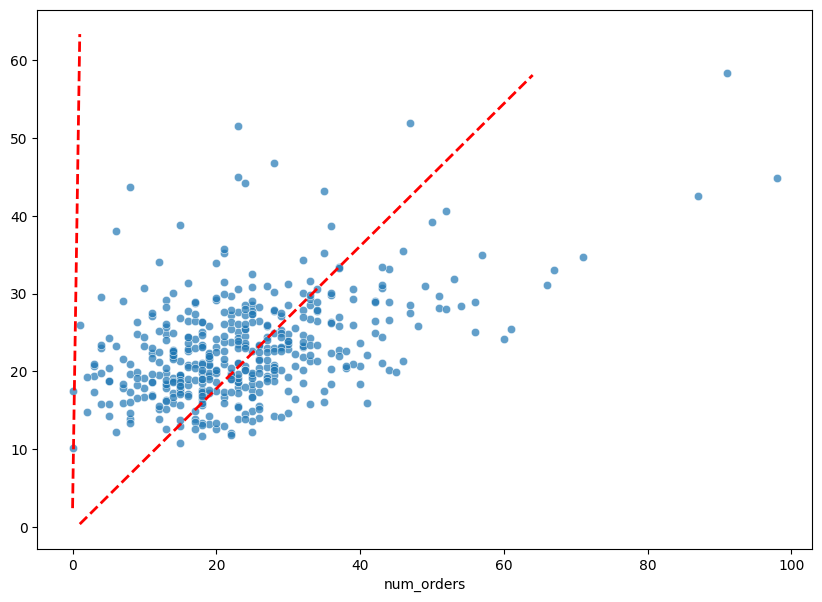

In [29]:
#Calcular as métricas para incluir no título/legenda
mse_valid = mean_squared_error(y_test, y_pred_dt)
rmse_valid = mean_squared_error(y_test, y_pred_rf) # REQM
r2_valid = r2_score(y_test, y_pred_gb)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7) # Plotar os pontos de dados
plt.plot([y_pred_dt.min(), y_pred_dt.max()], [y_pred_rf.min(), y_pred_rf.max()], [y_pred_gb.min(), y_pred_gb.max()], color='red', linestyle='--', lw=2, label='Linha Ideal (Previsão = Real)') # Linha de referência ideal

**Conclusão**

Há uma dispersão de pontos que parece ter uma correlação positiva (conforme a nuvem de pontos tende a subir da esquerda para a direita), mas com uma variabilidade considerável em torno da linha diagonal. 

In [30]:
#Treinando modelo de Gradient Boosting
model_gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train, y_train)

print("Modelo Gradient Boosting Regressor treinado com sucesso!")

Modelo Gradient Boosting Regressor treinado com sucesso!


In [31]:
y_pred_gb = model_gb.predict(X_test)

print(f"Primeiras 5 previsões do Gradient Boosting:\n{y_pred_gb[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Gradient Boosting:
[16.18639342 21.54095396 26.45878941 26.1814832  20.71368885]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [32]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Gradient Boosting: {mse_gb:.2f}")
print(f"R-squared (R2) do Gradient Boosting: {r2_gb:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Gradient Boosting: 93.87
R-squared (R2) do Gradient Boosting: 0.45


In [33]:
#Treinando modelo de Random Forest
model_rf = RandomForestRegressor(n_estimators=150, random_state=42)
model_rf.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


In [34]:
y_pred_rf = model_rf.predict(X_test)

print(f"Primeiras 5 previsões do Random Forest:\n{y_pred_rf[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Random Forest:
[15.70777778 16.21277778 23.04166667 25.57722222 24.33333333]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [35]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Random Forest: {mse_rf:.2f}")
print(f"R-squared (R2) do Random Forest: {r2_rf:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Random Forest: 103.62
R-squared (R2) do Random Forest: 0.39


In [36]:
#Treinando modelo de Regressão de Árvores
model_dt = DecisionTreeRegressor(max_depth=11, random_state=42)
model_dt.fit(X_train, y_train)

print("Modelo Decision Tree Regressor treinado com sucesso!")

Modelo Decision Tree Regressor treinado com sucesso!


In [37]:
y_pred_dt = model_dt.predict(X_test)

print(f"Primeiras 5 previsões do Decision Tree:\n{y_pred_dt[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Decision Tree:
[14.87804878  9.         32.         27.         27.        ]
Primeiros 5 valores reais (y_test):
[13 41 26 18 30]


In [38]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
#Calcular O REQM
rmse = math.sqrt(mse)
print(f'REQM: {rmse:.2f}')
print(f"Mean Absolute Error (MAE) do Decision Tree: {mse_dt:.2f}")
print(f"R-squared (R2) do Decision Tree: {r2_dt:.2f}")

REQM: 11.58
Mean Absolute Error (MAE) do Decision Tree: 143.06
R-squared (R2) do Decision Tree: 0.16


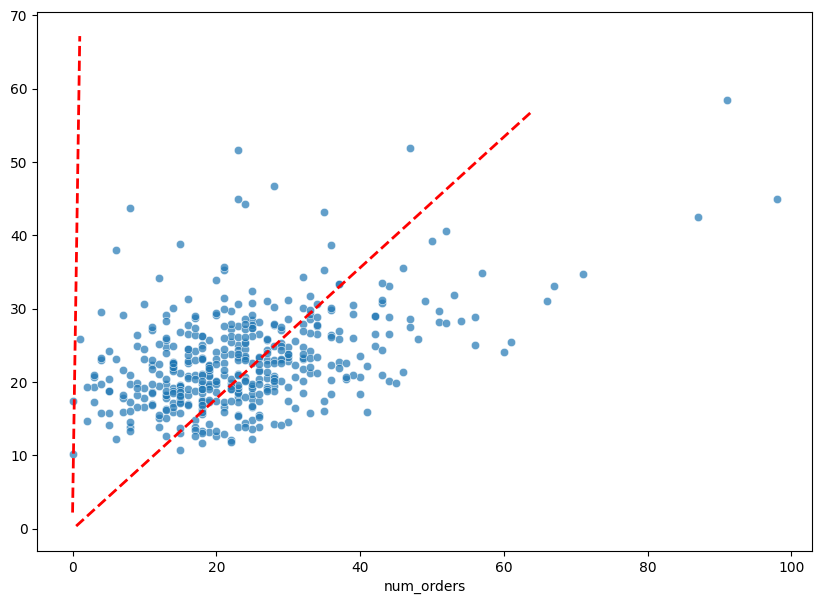

In [39]:
#Calcular as métricas para incluir no título/legenda
mse_valid = mean_squared_error(y_test, y_pred_dt)
rmse_valid = mean_squared_error(y_test, y_pred_rf) # REQM
r2_valid = r2_score(y_test, y_pred_gb)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7) # Plotar os pontos de dados
plt.plot([y_pred_dt.min(), y_pred_dt.max()], [y_pred_rf.min(), y_pred_rf.max()], [y_pred_gb.min(), y_pred_gb.max()], color='red', linestyle='--', lw=2, label='Linha Ideal (Previsão = Real)') # Linha de referência ideal

**Conclusão**

Há uma distribuição onde a maioria das ocorrências tem poucos pedidos, mas há uma tendência positiva entre o número de pedidos e a outra métrica, embora esta métrica tenda a ser inferior ao número de pedidos para a maioria das observações.
Sendo dois gráficos bem semelhantes.

**Conclusões**

Os dados revelam que o serviço apresenta um forte padrão de atividade, com picos de pedidos concentrados nas segundas-feiras e nas horas noturnas/madrugada. Em contraste, as manhãs e os domingos são os períodos de menor movimento.
A presença constante de outliers em todos os padrões temporais sugere uma volatilidade intrínseca, com eventos esporádicos de grande volume de pedidos que fogem à norma diária ou semanal.
Essas informações são cruciais para a otimização de recursos, planejamento de equipes (especialmente para as madrugadas de domingo para segunda-feira), estratégias de marketing e logística, permitindo ao negócio se adaptar aos fluxos de demanda.

Nathália Sorg